# Analyse stimulus history and plot exposure traces

Requires information from stimulus log file and recording field positions from `.smh`header files; for this specific analysis, the data is already consolidated in a `.cvs`file (see below).

In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib import colors
import numpy as np

HERE = os.getcwd()
sys.path.append(HERE)
sys.path.append(os.path.join(HERE, "..", "..", "utils"))
from light_exposure.stim_utils.stimulus import stim_movies, stim_outlines
from data_io import get_data_config, REPO_ROOT

In [9]:
# Get paths from `data_config.yaml` paths 
DATA_2P = (Path(REPO_ROOT) / "notebooks" / get_data_config()["data_2p_dir"]).resolve()

# Use compressed .npz files for stimuli-as-movies
STIM_MOV_EXT = ".npz"
STIM_MOV_PATH = DATA_2P / "stimuli-as-movies"

# Load consolidated experiment overview 
CONSOL_PATH = Path(HERE) / "light_exposure" /"experiment-overview_consolidated.csv"

# Create figures directory if it doesn't exist
FIG_DIR = os.path.join(HERE, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

### Define stimulus parameters ...

... to determine the illuminated area and mean illumination for the stimuli.   

Approx. field of view of stimulus through objective lens for setup #1:
- ~1.0 mm for Zeiss W Plan-Apochromat (20x/1,0 DIC M27) - this was used for the EW2 experiments
- ~1.5 mm for Nikon 16x objective (CF175 LWD×16/0.8W, DIC N2) - this is currently used

In [10]:
# Approx. field of view of stimulus through objective lens
FOV_diam = 1000  

# Define parameters for each stimulus type
stim_DS = dict(
    {'barDx_um': 1000.0, 
     'barDy_um': 300.0, 
     'nTrials': 3, 
     'vel_umSec': 1000.0, 
     'tMoveDur_s': 4.0, 
     'DirList': [0, 180, 45, 225, 90, 270, 135, 315], 
     'barColor': (255, 255, 255), 
     'bkgColor': (0, 0, 0)}
)
lEdge = stim_DS["barDy_um"]
trajLen = stim_DS["tMoveDur_s"] *stim_DS["vel_umSec"] +stim_DS["barDx_um"]
mb = stim_outlines.movingBar(lEdge, trajLen, stim_DS["DirList"], FOV_diam=FOV_diam)

stim_Chirp = dict(
    {'tSteadyON_s': 3.0, 
     'tSteadyOFF2_s': 2.0, 
     'tSteadyMID_s': 2.0, 
     'chirpMaxFreq_Hz': 8.0, 
     'tSteadyOFF_s': 3.0, 
     'ContrastFreq_Hz': 2.0, 
     'nTrials': 5, 
     'dxStim_um': 1000, 
     'IHalf': 127, 
     'chirpDur_s': 8.0, 
     'IFull': 254}
)
chirp = stim_outlines.spot(diam=stim_Chirp["dxStim_um"], FOV_diam=FOV_diam)

stim_MouseCam_Left = dict(
    {'movparams_Train': {'nFr': 16200, 'dyFr': 56, 'dxFr': 56}, 
     'movName_Train': '//Katrin//RGCs//train_images_right.jpg', 
     'nFrRepeats': 2, 
     'movparams_Test': {'nFr': 750, 'dyFr': 56, 'dxFr': 56}, 
     'FrameRateMovie': 30.0, 
     'movName_Test': '//Katrin//RGCs//test_images_rand_right.jpg', 
     'movScale': (12.5, 12.5), 
     'movAlpha': 255, 
     'movOrient': 0, 
     'nFrPerMarker': 3, 
     'IndexName': 'RandomSequences', 
     'nTrials': 1, 
     'durSnippet_s': 5.0}
)
mcam_dx = stim_MouseCam_Left["movparams_Train"]["dxFr"] *stim_MouseCam_Left["movScale"][0]
mcam_dy = stim_MouseCam_Left["movparams_Train"]["dyFr"] *stim_MouseCam_Left["movScale"][1]
mouseMovie = stim_outlines.box(mcam_dx, mcam_dy, FOV_diam=FOV_diam)

### Get stimulus sequence and recording positions

Load currated file with stimulus and recording data.

_Note: Bringing together the data from the `.smh` files and the stimulus log file automatically is a bit tricky, as the data here was recorded on two PCs with not well synchronized clocks. Hence, the manually currated file. But since we do not need absolute time, this does not matter for the following analysis. One other caveat is that scan position was not recorded in the QDSpy `.log`; having field positions there also for focus scans (where no recording file is written) would have been useful._

In [11]:
df = pd.read_csv(CONSOL_PATH, on_bad_lines='warn', sep=';')

## Generate an overview of the stimulus presentation and recording fields (deprecated)

For plotting overview of recording fields and illuminated areas, set `False` in first line to `True`

In [13]:
if False:
    # Create figure for plotting
    fig, ax = plt.subplots(figsize=(5, 5))

    # Get time range for colormap normalization (only for rows with position data)
    df_with_pos = df[df['pos_xyz'].notna()].copy()
    if len(df_with_pos) > 0:
        t_min = df_with_pos['t_abs_s'].min()
        t_max = df_with_pos['t_abs_s'].max()
    else:
        t_min, t_max = 0, 1

    # Create colormap (using 'brg' - blue-red-green)
    norm = Normalize(vmin=t_min, vmax=t_max)
    cmap = cm.brg

    # The alpha value equivalent to 1 sec stimulus exposure
    alpha_per_s = 0.001

    for index, row in df.iterrows():
        # Get coordinates 
        if row["pos_xyz"] is not np.nan:
            s = row["pos_xyz"][1:-1].split(",")
            pos_xyz = [float(s[i]) for i in range(len(s))]
        else:
            pos_xyz = None    

        # Get other parameters
        fStimName = row["stimFileName"]
        fRecName = "" if row["dataFileName"] is np.nan else row["dataFileName"]
        t_abs_s = row["t_abs_s"]
        t_dur_s = row["t_dur_s"]
        
        if pos_xyz and not(pos_xyz == [0,0,0]):
            # Plot stimuli only for presentations w/ position data
            x0, y0 = pos_xyz[0], pos_xyz[1]
            
            # Get color based on time
            edge_color = cmap(norm(t_abs_s))
            
            if fStimName.upper() in ["DS"]:
                # Plot moving bar outline at the current position
                poly = stim_outlines.movingBar(lEdge, trajLen, MovingBar["DirList"], x0=x0, y0=y0, FOV_diam=FOV_diam)
                x, y = poly.exterior.xy

                # Adjusting exposure to presentation duration and mean intensity (estimate)
                # TODO: Better estimate
                expos = min(1, t_dur_s *alpha_per_s *0.2)
                
                # Fill first (lower z-order), outline on top (higher z-order)
                ax.fill(x, y, color='yellow', alpha=expos, zorder=1)
                ax.plot(x, y, color=edge_color, linewidth=1.5, zorder=5)

            elif fStimName in ["Chirp"]:
                # Plot chirp outline at the current position
                poly = stim_outlines.spot(diam=RGC_Chirp["dxStim_um"], x0=x0, y0=y0, FOV_diam=FOV_diam)
                x, y = poly.exterior.xy

                # Adjusting exposure to presentation duration and mean intensity (estimate)
                # TODO: Better estimate
                expos = min(1, t_dur_s *alpha_per_s *0.5)
                
                # Fill first (lower z-order), outline on top (higher z-order)
                ax.fill(x, y, color='yellow', alpha=expos, zorder=1)
                ax.plot(x, y, color=edge_color, linewidth=1.5, zorder=5)

            elif fStimName in ["MouseCam_Right"]:
                # Plot movie outline at the current position
                poly = stim_outlines.box(mcam_dx, mcam_dy, x0=x0, y0=y0, FOV_diam=FOV_diam)
                x, y = poly.exterior.xy

                # Adjusting exposure to presentation duration and mean intensity (estimate)
                # TODO: Better estimate
                expos = min(1, t_dur_s *alpha_per_s *0.5)
                
                # Fill first (lower z-order), outline on top (higher z-order)
                ax.fill(x, y, color='yellow', alpha=expos, zorder=1)
                ax.plot(x, y, color=edge_color, linewidth=1.5, zorder=5)

    # Add scatter points for recording positions
    df_valid = df[df['pos_xyz'].notna()].copy()
    df_valid['x'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[0]))
    df_valid['y'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[1]))
    sc = ax.scatter(df_valid['x'], df_valid['y'], c=df_valid['t_abs_s'], cmap='brg', 
                    s=20, marker='o', zorder=10, edgecolor='k', linewidth=0.5)

    # Add colorbar with same height as the plot
    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Time (s from start)')

    ax.set_xlabel('X [um]')
    ax.set_ylabel('Y [um]')
    ax.set_title('Stimulus Presentation Map (colored by time)')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'stimulus_presentation_map.pdf'))
    plt.show()

## Generate a map of the stimulus presentation (using movies)

### Load stimulus movie files into numpy array

... and zero blue channel, as it was not used (green=G, red=UV?)

In [14]:
# Load moving bar stimulus
tmp_path = Path.joinpath(STIM_MOV_PATH, "DS" +STIM_MOV_EXT)
mov_DS = stim_movies.load_qdspy_movie(tmp_path)
mov_DS[:,:,:,2] = 0

# Load chirp stimulus
tmp_path = Path.joinpath(STIM_MOV_PATH, "Chirp" +STIM_MOV_EXT)
mov_Chirp = stim_movies.load_qdspy_movie(tmp_path)
mov_Chirp[:,:,:,2] = 0

# Load natural movie (MouseCam_Left) stimulus
tmp_path = Path.joinpath(STIM_MOV_PATH, "MouseCam_Left" +STIM_MOV_EXT)
mov_MouseCamLeft = stim_movies.load_qdspy_movie(tmp_path)
mov_MouseCamLeft[:,:,:,2] = 0

Loading file from: C:\Users\teuler\Documents\git\huggingface\eyewire2-data\data-2p\stimuli-as-movies\DS.npz
Done.
Loading file from: C:\Users\teuler\Documents\git\huggingface\eyewire2-data\data-2p\stimuli-as-movies\Chirp.npz
Done.
Loading file from: C:\Users\teuler\Documents\git\huggingface\eyewire2-data\data-2p\stimuli-as-movies\MouseCam_Left.npz
Done.


### Define global parameters, field positions, and colors for plotting

In [15]:
# Define spatial scaling (pixel size from moving bar width/bar pixels in downsampled movies generated by QDSpy)
_, dx, dy, _ = mov_DS.shape
px_um = 300 /7  

# Define some global parameters for plotting and analysis
params = dict({
    "pix_size_um": px_um,
    "mov_dxy": [dx, dy],
    "mov_dxy_um": [px_um *dx, px_um *dy],
    "dt_fr_s": 1 /60,
    "nCh": 2,
    "rec_field_dxy_um": [95, 95],
    "surr_factor": 2.0,    
    "sel_chan": "Green",
    "tau_adapt_s": 60*4
})

# Define field locations (and colors for plot)
fields = [
    {"field": 0, "pos_xy_um": [1478.2,-557.4]},
    {"field": 1, "pos_xy_um": [1522.4,-637.8]},
    {"field": 2, "pos_xy_um": [1522.4,-413.8]},
    {"field": 3, "pos_xy_um": [1281.6,-464.0]},
    {"field": 4, "pos_xy_um": [1350.0,-777.0]}
]

# Define colors for each field (for plotting)
field_colors = [
    colors.to_rgba("orange"),
    colors.to_rgba("orangered"),
    colors.to_rgba("seagreen"),
    colors.to_rgba("dodgerblue"),
    colors.to_rgba("slateblue")
]

### Define functions to generate exposure spatio-temporal plots

`calc_spatial_exposure()` extracts exposure data for the given range of stimulus presentations (as lines in the consolidated stimulus protocol file `fLogConsol`). The function generates the plot, if requested, as well as a structure `movie_data`, which contains for every line in the stimulus protocol the exposure movie.   

`calc_temporal_exposure()` uses `_mov_data` to calculate the temporal exposure traces (mean and cumulative intensity) and plot them, if requested.

In [16]:
def calc_spatial_exposure(
        fLogConsol: Path, _p: dict, ln_range: list =[0, 1000], 
        _plot: bool =True, _verbose: bool =True        
    ):
    """ Generate exposure data for the given range of stimulus presentations 
        (as lines in the consolidated stimulus protocol file `fLogConsol`)
        The function generates the plot as well as a structure `movie_data`, which contains 
        for every line in the stimulus protocol the exposure movie. 
    """    
    # Read consolidated experiment protocol
    df = pd.read_csv(fLogConsol, on_bad_lines='warn', sep=';')

    # Get some general parameters
    nCh = _p["nCh"]

    # Recording field size and factor by which to increase recording field area
    # for intensity exposure traces
    rec_field_dxy_um = _p["rec_field_dxy_um"]
    surr_factor = _p["surr_factor"]    

    # Determine the extent of the experiment area to create accumulator array
    df_valid = df[df['pos_xyz'].notna()].copy()
    df_valid['x'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[0]))
    df_valid['y'] = df_valid['pos_xyz'].apply(lambda v: float(v[1:-1].split(',')[1]))

    # Set fixed bounds for the display area
    x_min = 500
    x_max = 2250
    y_min = -1250
    y_max = 250

    # Create accumulator array for the summary picture
    pix_size_um = _p["pix_size_um"]
    acc_width_px = int((x_max - x_min) / pix_size_um)
    acc_height_px = int((y_max - y_min) / pix_size_um)
    acc_image = np.zeros((acc_height_px, acc_width_px, _p["nCh"]), dtype=np.float64)
    if _verbose:
        print(f"Accumulator image size: {acc_width_px} x {acc_height_px} pixels")
        print(f"Spatial extent: X=[{x_min:.1f}, {x_max:.1f}] um, Y=[{y_min:.1f}, {y_max:.1f}] um")

    # Create variables to hold arrays for intensity-time plots
    movie_data = []
    
    for index, row in df.iterrows():
        # Restrict to part of the experiment
        if index < ln_range[0] or index > ln_range[1]:
            continue

        # Get coordinates 
        if row["pos_xyz"] is not np.nan:
            s = row["pos_xyz"][1:-1].split(",")
            pos_xyz = [float(s[i]) for i in range(len(s))]
        else:
            pos_xyz = None    

        # Get other parameters
        fStimName = row["stimFileName"]
        fRecName = "" if row["dataFileName"] is np.nan else row["dataFileName"]
        t_abs_s = row["t_abs_s"]
        t_dur_s = row["t_dur_s"]
        
        if pos_xyz:
            # Consider only stimuli w/ position data
            x0, y0 = pos_xyz[0], pos_xyz[1]
            print(f"#{index:2d} {fStimName:20s} x,y={x0:.0f},{y0:.0f}")

            # Generate flattened stimulus movie and add it to the exposure picture
            if fStimName.upper() in ["DS"]:
                _mov = mov_DS
            elif fStimName.upper() in ["CHIRP"]:
                _mov = mov_Chirp
            elif fStimName.upper() in ["MOUSECAM_RIGHT"]:
                _mov = mov_MouseCamLeft
            else:
                _mov = None

            # Collect data to generate intensity traces later
            tmp = dict({
                "index": index,
                "movie": None if x0 == 0 and y0 == 0 else _mov,
                "field_size_um": [v *surr_factor for v in rec_field_dxy_um],
                "field_xy_um": [x0, y0],
                "t_abs_s": t_abs_s,
                "t_dur_s": t_dur_s,
                "t_since_last_s": row["t_since_last_s"],
                "fieldID": int(row["fieldID"]),
                "t_field_start_s": row["t_field_start_s"],
                "t_field_end_s": row["t_field_end_s"]
            })
            movie_data.append(tmp)
            if _mov is None:
                continue

            # Flatten movie    
            mov_flat = stim_movies.flatten_movie(_mov, _p, _range_s=[0, t_dur_s])

            # Ensure the movie has the correct number of channels
            mov_h, mov_w, mov_ch = mov_flat.shape
            if mov_ch != nCh:
                # Take only the first nCh channels
                mov_flat = mov_flat[:, :, :nCh]
            
            # Calculate position in accumulator array
            # Movie center is at (x0, y0), movie origin is at top-left
            mov_h, mov_w, _ = mov_flat.shape
            mov_center_x_um = x0
            mov_center_y_um = y0
            
            # Convert to pixel coordinates in accumulator
            # Note: Image coordinates have origin at top-left, so we need to flip y
            acc_center_x_px = int((mov_center_x_um - x_min) / pix_size_um)
            acc_center_y_px = int((mov_center_y_um - y_min) / pix_size_um)
            
            # Calculate bounds for placing the movie
            acc_x0 = acc_center_x_px - mov_w // 2
            acc_x1 = acc_x0 + mov_w
            acc_y0 = acc_center_y_px - mov_h // 2
            acc_y1 = acc_y0 + mov_h
            
            # Clip to accumulator bounds and add
            mov_x0 = max(0, -acc_x0)
            mov_x1 = mov_w - max(0, acc_x1 - acc_width_px)
            mov_y0 = max(0, -acc_y0)
            mov_y1 = mov_h - max(0, acc_y1 - acc_height_px)
            
            acc_x0_clip = max(0, acc_x0)
            acc_x1_clip = min(acc_width_px, acc_x1)
            acc_y0_clip = max(0, acc_y0)
            acc_y1_clip = min(acc_height_px, acc_y1)
            
            # Add the flattened movie to accumulator
            acc_image[acc_y0_clip:acc_y1_clip, acc_x0_clip:acc_x1_clip, :] += \
                mov_flat[mov_y0:mov_y1, mov_x0:mov_x1, :]

    # Normalize the accumulated image for display
    acc_image_norm = acc_image / (acc_image.max() + 1e-10)
    spatial_extent = dict(x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max)

    if _plot:
        # Create figure for plotting of exposure images
        fig, axes = plt.subplots(1, _p["nCh"], figsize=(10, 5))
        if nCh == 1:
            axes = [axes]

        colors = ['violet', 'green', 'blue']
        for ch in range(nCh):
            _ = axes[ch].imshow(acc_image_norm[:, :, ch], cmap='gray', 
                                extent=[x_min, x_max, y_max, y_min], 
                                origin='upper', aspect='equal')
            axes[ch].set_xlabel('X [um]')
            axes[ch].set_ylabel('Y [um]')
            axes[ch].set_title(f'Channel {ch} ({colors[ch]})')
            axes[ch].set_xlim(x_min, x_max)
            axes[ch].set_ylim(y_min, y_max)
            
            # Draw gray rectangles centered at recording positions
            from matplotlib.patches import Rectangle
            rec_size = rec_field_dxy_um[0]
            for _, row_data in df_valid.iterrows():
                c = field_colors[int(row_data["fieldID"])]
                rect = Rectangle((row_data['x'] - rec_size/2, row_data['y'] - rec_size/2),
                                rec_size, rec_size,
                                linewidth=1, edgecolor=c, facecolor='none', zorder=9)
                axes[ch].add_patch(rect)
            
            # Add scatter points for recording positions
            axes[ch].scatter(df_valid['x'], df_valid['y'], c='red', 
                            s=20, marker='o', zorder=10, edgecolor='k', linewidth=0.5)
            
            #axes[ch].grid(True, alpha=0.3)

        plt.tight_layout()
        fig.savefig(os.path.join(FIG_DIR, 'exposure_spatial.svg'),
            format='svg',
            bbox_inches='tight',  # Removes extra whitespace
            dpi=300,              # Higher resolution
            transparent=True)     # White background
        plt.show()

    return movie_data, acc_image_norm, spatial_extent, df_valid

In [17]:
def calc_temporal_exposure(
        _mov_data: list, _p: dict, 
        _plot: bool =True, _verbose=False
    ):
    """ From `_mov_data` calculate the temporal exposure traces (mean and cumulative 
        intensity) and plot them, if required
    """
    # Prepare arrays for traces
    f_int_mean = [None] *len(fields)
    f_int_cumul = [None] *len(fields)
    f_adapted_activity = [None] * len(fields)

    # Get/define general parameter(s)
    dt_fr_s = _p["dt_fr_s"]
    t_marks = {"t0_s": [], "t1_s": [], "fID": []}

    for _ip, _pres in enumerate(_mov_data):
        if _verbose:
            print(f"presentation index {_pres["index"]}")

        # Get start time and duration
        t_abs_s = _pres["t_abs_s"] 
        t_dur_s = _pres["t_dur_s"]
        t_since_last_s = _pres["t_since_last_s"]
        if _verbose:
            print("t_abs_s=", t_abs_s, "t_dur_s=", t_dur_s, "t_since_last_s=", t_since_last_s)

        # Get field ID to determine transitions between fields
        t =  _pres["t_field_start_s"]
        if t > 0:
            t_marks["t0_s"].append(t)
            t_marks["fID"].append(_pres["fieldID"])
        t =  _pres["t_field_end_s"]
        if t > 0:
            t_marks["t1_s"].append(t)

        # Consider the gap between the last stimulus end and the start of this
        if _ip == 0:
            n_gap_fr = 0
            t_curr_end_s = t_dur_s
        else:
            n_gap_fr = round(t_since_last_s /dt_fr_s)
            t_curr_end_s += t_since_last_s +t_dur_s
        if _verbose:
            print("t_curr_end_s=", t_curr_end_s, "n_gap_fr=", n_gap_fr)    

        # Go over all fields ...
        for _if, _fld in enumerate(fields):
            # Get positional offset between stimulus (movie) centre and field centre
            x = _pres["field_xy_um"][0] -_fld["pos_xy_um"][0]
            y = _pres["field_xy_um"][1] -_fld["pos_xy_um"][1]
            
            # If move exists ...
            if _pres["movie"] is None:
                # No stimulus movie because projected elsewhere
                n = int(t_dur_s /dt_fr_s)
                intens = np.zeros((n, f_int_mean[_if].shape[1]), dtype=np.float64)
            else:
                # Get intensity traces for this presentation for this field
                intens, _ = stim_movies.calc_intensity_trace(
                    _pres["movie"], _p, _range_s=[0, t_dur_s],
                    _field_xy_um=[x,y],
                    _field_size_um=_pres["field_size_um"],
                    _plot=False
                )
                if _verbose:
                    print("_if=", _if, "x,y=", [int(x),int(y)], "t_dur_s=", t_dur_s)

            # Copy traces into the structure that holds the traces of the experiment
            if _ip == 0:
                f_int_mean[_if] = np.copy(intens)
            else:
                if n_gap_fr > 0:
                    tmp = np.zeros((n_gap_fr, f_int_mean[_if].shape[1]), dtype=np.float64)
                    f_int_mean[_if] = np.concatenate([f_int_mean[_if], tmp])
                f_int_mean[_if] = np.concatenate([f_int_mean[_if], intens])
            
            if _verbose:
                print("length=", f_int_mean[_if].shape[0], 
                    f_int_mean[_if].shape[0] *dt_fr_s, "len(intens)=", len(intens)
                )
            
    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  
    # For each field, calculate the cumulative intensity and adapted activity ...
    for _if, _fld in enumerate(fields):
        # Cumulative intensity ...
        f_int_cumul[_if] = np.cumsum(f_int_mean[_if], axis=0) * dt_fr_s

        # Adapting activity ...
        I = f_int_mean[_if]  # shape: (n_frames, n_channels)
        n_frames, n_ch = I.shape
        activity = np.zeros_like(I, dtype=np.float64)
        
        # Decay constant: activity -= activity/tau each frame
        decay_rate = dt_fr_s / _p["tau_adapt_s"]
        
        for t in range(1, n_frames):
            # Exponential decay of activity (mimics recovery) and add new intensity
            activity[t] = activity[t-1] * (1.0 - decay_rate)
            activity[t] += I[t]
        
        f_adapted_activity[_if] = activity

    # - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  
    if _plot:
        # Plot f_int_mean and f_int_cumul over time - all fields in one plot
        y_scaler = 300
        selected_channel = _p["sel_chan"]
        channel_names = ['UV', 'Green']
        channel_idx = channel_names.index(selected_channel)

        # Create figure with three subplots
        fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

        # Plot f_int_mean (mean intensity)
        for _if, _fld in enumerate(fields):
            intensity_data = f_int_mean[_if]
            n_frames = intensity_data.shape[0]
            t_axis = np.arange(n_frames) * dt_fr_s 
            axes[0].plot(t_axis, intensity_data[:, channel_idx] +_if*y_scaler,
                        label=f'Field {_fld["field"]}', 
                        color=field_colors[_if],
                        linewidth=1.0,
                        alpha=0.8)
                
        axes[0].set_ylabel('Mean Intensity')
        axes[0].set_title(f'{selected_channel} Channel - Mean Intensity (All Fields)')
        axes[0].grid(True, alpha=0.3)
        
        # Plot f_int_cumul (cumulative intensity)
        for _if, _fld in enumerate(fields):
            # Get the cumulative intensity data for this field
            cumul_data = f_int_cumul[_if]
            n_frames = cumul_data.shape[0]
            t_axis = np.arange(n_frames) * dt_fr_s
            axes[1].plot(t_axis, cumul_data[:, channel_idx], #+_if*y_scaler, 
                        label=f'Field {_fld["field"]}', 
                        color=field_colors[_if],
                        linewidth=1.0,
                        alpha=0.8)
            
        axes[1].set_ylabel('Cumulative Intensity')
        axes[1].set_title(f'{selected_channel} Channel - Cumulative Intensity (All Fields)')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xlabel('Time (s)')

        # Plot f_adapted_activity
        for _if, _fld in enumerate(fields):
            activity_data = f_adapted_activity[_if]
            n_frames = activity_data.shape[0]
            t_axis = np.arange(n_frames) * dt_fr_s
            axes[2].plot(t_axis, activity_data[:, channel_idx], #+_if*y_scaler, 
                        label=f'Field {_fld["field"]}', 
                        color=field_colors[_if],
                        linewidth=1.0,
                        alpha=0.8)

        axes[2].set_ylabel('Adapted Activity')
        axes[2].set_title(f'{selected_channel} Channel - Adapted Activity (τ={_p["tau_adapt_s"]}s, All Fields)')
        axes[2].set_xlabel('Time (s)')
        axes[2].grid(True, alpha=0.3)
                
        # Plot time marks
        if _verbose:
            print(t_marks)
        nt1 = len(t_marks["t1_s"])
        for it in range(len(t_marks["t0_s"])):
            t0 = t_marks["t0_s"][it] -t_marks["t0_s"][0]
            if nt1 < it:
                t1 = t_marks["t1_s"][it] -t_marks["t0_s"][0]
            c = field_colors[t_marks["fID"][it]]
            for j in range(3):
                axes[j].axvline(x=t0, color=c, linestyle='--', linewidth=1.5, alpha=0.7)
                if nt1 < it:
                    axes[j].axvline(x=t1, color=c, linestyle='--', linewidth=1.5, alpha=0.7)

        # Create a single shared legend outside and to the right of the plots
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)

        plt.tight_layout()
        plt.show()
        fig.savefig(os.path.join(FIG_DIR, 'exposure_temporal.svg'),
            format='svg',
            bbox_inches='tight',  # Removes extra whitespace
            dpi=300,              # Higher resolution
            transparent=True)     # White background

    return f_int_mean, f_int_cumul, f_adapted_activity, t_marks

In [18]:
def plot_exposure_summary(
        _movie_data: list, _spatial_extent: dict, _df_valid: pd.DataFrame,
        _f_int_mean: list, _f_adapted_activity: list, _t_marks: dict, _p: dict,
        _ch_map: int =0, ln_range: list =[0, 1000], _save: bool =True
    ):
    """ Combined summary figure: exposure map (channel `_ch_map`) on the left, mean 
        intensity and adapted activity stacked on the right. The right panel is 1.3x 
        the width of the left panel; both panels span the same total height.

        `ln_range` selects presentations by line index into the consolidated stimulus 
        protocol - exactly as in `calc_spatial_exposure()` - and both the exposure map 
        and the right-hand panels are restricted to that same selection.
    """
    from matplotlib.patches import Rectangle
    from matplotlib.gridspec import GridSpec
    from matplotlib.transforms import Affine2D

    dt_fr_s = _p["dt_fr_s"]
    rec_field_dxy_um = _p["rec_field_dxy_um"]
    channel_names = ['UV', 'Green']
    channel_idx = channel_names.index(_p["sel_chan"])
    x_min, x_max = _spatial_extent["x_min"], _spatial_extent["x_max"]
    y_min, y_max = _spatial_extent["y_min"], _spatial_extent["y_max"]

    # Select the presentations covered by `ln_range`, the same way
    # `calc_spatial_exposure()` uses it to select presentations by line index
    t_end_full = _f_int_mean[0].shape[0] * dt_fr_s
    t0_ref = _t_marks["t0_s"][0]
    sel = [pres for pres in _movie_data if ln_range[0] <= pres["index"] <= ln_range[1]]
    if sel:
        t_lo = min(pres["t_abs_s"] for pres in sel) - t0_ref
        t_hi = max(pres["t_abs_s"] +pres["t_dur_s"] for pres in sel) - t0_ref
    else:
        t_lo, t_hi = 0.0, t_end_full

    # Re-accumulate the exposure map from just the selected presentations - same
    # placement logic as `calc_spatial_exposure()`, restricted to this selection
    pix_size_um = _p["pix_size_um"]
    nCh = _p["nCh"]
    acc_width_px = int((x_max - x_min) / pix_size_um)
    acc_height_px = int((y_max - y_min) / pix_size_um)
    acc_image = np.zeros((acc_height_px, acc_width_px, nCh), dtype=np.float64)
    for pres in sel:
        if pres["movie"] is None:
            continue
        x0, y0 = pres["field_xy_um"]
        mov_flat = stim_movies.flatten_movie(pres["movie"], _p, _range_s=[0, pres["t_dur_s"]])
        mov_h, mov_w, mov_ch = mov_flat.shape
        if mov_ch != nCh:
            mov_flat = mov_flat[:, :, :nCh]
        mov_h, mov_w, _ = mov_flat.shape

        acc_center_x_px = int((x0 - x_min) / pix_size_um)
        acc_center_y_px = int((y0 - y_min) / pix_size_um)
        acc_x0 = acc_center_x_px - mov_w // 2
        acc_x1 = acc_x0 + mov_w
        acc_y0 = acc_center_y_px - mov_h // 2
        acc_y1 = acc_y0 + mov_h

        mov_x0 = max(0, -acc_x0)
        mov_x1 = mov_w - max(0, acc_x1 - acc_width_px)
        mov_y0 = max(0, -acc_y0)
        mov_y1 = mov_h - max(0, acc_y1 - acc_height_px)

        acc_x0_clip = max(0, acc_x0)
        acc_x1_clip = min(acc_width_px, acc_x1)
        acc_y0_clip = max(0, acc_y0)
        acc_y1_clip = min(acc_height_px, acc_y1)

        acc_image[acc_y0_clip:acc_y1_clip, acc_x0_clip:acc_x1_clip, :] += \
            mov_flat[mov_y0:mov_y1, mov_x0:mov_x1, :]
    acc_image_norm = acc_image / (acc_image.max() + 1e-10)

    fig = plt.figure(figsize=(13, 5))
    gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1.3], hspace=0.2, wspace=0.1)
    ax_map = fig.add_subplot(gs[:, 0])
    ax_mean = fig.add_subplot(gs[0, 1])
    ax_adapt = fig.add_subplot(gs[1, 1], sharex=ax_mean)

    # Left panel: exposure map for the selected channel, rotated 90 deg to the left
    trans = Affine2D().rotate_deg(90) + ax_map.transData
    ax_map.imshow(acc_image_norm[:, :, _ch_map], cmap='gray',
                extent=[x_min, x_max, y_max, y_min],
                origin='upper', transform=trans)
    ax_map.set_xlim(-y_max, -y_min)
    ax_map.set_ylim(x_min, x_max)
    ax_map.set_aspect('equal')
    ax_map.set_xticks([])
    ax_map.set_yticks([])

    rec_size = rec_field_dxy_um[0]
    for _, row_data in _df_valid.iterrows():
        c = field_colors[int(row_data["fieldID"])]
        rect = Rectangle((row_data['x'] - rec_size/2, row_data['y'] - rec_size/2),
                        rec_size, rec_size,
                        linewidth=1, edgecolor=c, facecolor='none', zorder=9,
                        transform=trans)
        ax_map.add_patch(rect)
    ax_map.scatter(_df_valid['x'], _df_valid['y'], c='red',
                s=20, marker='o', zorder=10, edgecolor='k', linewidth=0.5,
                transform=trans)

    # Connector lines from each recording field's box to its label ("F0", "F1", ...),
    # radiating outward from the cluster centroid so labels spread around the boxes
    line_len_um = 150
    label_gap_um = 15
    centroid = np.mean([f["pos_xy_um"] for f in fields], axis=0)
    for _if, _fld in enumerate(fields):
        c = field_colors[_if]
        fx, fy = _fld["pos_xy_um"]
        ddx, ddy = fx - centroid[0], fy - centroid[1]
        dist = np.hypot(ddx, ddy)
        ux, uy = (ddx /dist, ddy /dist) if dist > 1e-6 else (0.7071, 0.7071)
        x0 = fx + rec_size/2 *ux
        y0 = fy + rec_size/2 *uy
        x1 = fx + (rec_size/2 +line_len_um) *ux
        y1 = fy + (rec_size/2 +line_len_um) *uy
        ax_map.plot([x0, x1], [y0, y1], color=c, linewidth=1, zorder=11, transform=trans)
        ax_map.text(x1 +label_gap_um *ux, y1 +label_gap_um *uy, f"F{_fld['field']}",
                    color=c, fontsize=13, ha='center', va='center', zorder=11, transform=trans)

    # Field-transition marks, sorted by time: mark k defines the start of field
    # `sorted_fid[k]`'s own recording; the cutoff for a field is the next mark's time
    t0_all = [t - t0_ref for t in _t_marks["t0_s"]]
    order = np.argsort(t0_all)
    sorted_t0 = [t0_all[i] for i in order]
    sorted_fid = [_t_marks["fID"][i] for i in order]
    cutoffs = {}
    for k, fid in enumerate(sorted_fid):
        if fid not in cutoffs:
            cutoffs[fid] = sorted_t0[k+1] if k+1 < len(sorted_t0) else None

    # Right panel, top: mean intensity, stacked vertically per field with enough
    # offset between neighbors that traces stay close but no longer overlap.
    # Field 0 (orange) is stacked at the top, the last field (lilac) at the bottom.
    mean_traces = []
    for _if in range(len(fields)):
        intensity_data = _f_int_mean[_if]
        t_axis = np.arange(intensity_data.shape[0]) * dt_fr_s
        m = (t_axis >= t_lo) & (t_axis <= t_hi)
        mean_traces.append((t_axis[m], intensity_data[m, channel_idx]))

    stack_step = 1.1 * max(trace.max() for _, trace in mean_traces)
    n_fields = len(fields)
    for _if, _fld in enumerate(fields):
        t_axis, trace = mean_traces[_if]
        ax_mean.plot(t_axis, trace + (n_fields -1 -_if) *stack_step,
                    label=f'Field {_fld["field"]}',
                    color=field_colors[_if], linewidth=1.0, alpha=0.8)
    ax_mean.set_ylabel('Intensity [a.u.]')
    ax_mean.set_title('Stimulus history')
    ax_mean.grid(True, alpha=0.3)
    plt.setp(ax_mean.get_xticklabels(), visible=False)

    # Right panel, bottom: adapted activity, unmodified - each field's full trace
    # (running from t=0) simply cut off at the point where the next field's own
    # recording starts (i.e. at that field's own dashed line)
    for _if, _fld in enumerate(fields):
        activity_full = _f_adapted_activity[_if][:, channel_idx]
        t_axis = np.arange(activity_full.shape[0]) * dt_fr_s

        cutoff = cutoffs.get(_if)
        m = (t_axis < cutoff) if cutoff is not None else np.ones_like(t_axis, dtype=bool)
        m &= (t_axis >= t_lo) & (t_axis <= t_hi)
        t_axis_seg, trace_seg = t_axis[m], activity_full[m]

        ax_adapt.plot(t_axis_seg, trace_seg,
                    label=f'Field {_fld["field"]}',
                    color=field_colors[_if], linewidth=1.0, alpha=0.8)
    ax_adapt.set_ylabel('Activation [a.u.]')
    ax_adapt.set_xlabel('Time (s)')
    ax_adapt.grid(True, alpha=0.3)

    # Field transition marks
    nt1 = len(_t_marks["t1_s"])
    for it in range(len(_t_marks["t0_s"])):
        t0 = _t_marks["t0_s"][it] - t0_ref
        c = field_colors[_t_marks["fID"][it]]
        if t_lo <= t0 <= t_hi:
            for ax in (ax_mean, ax_adapt):
                ax.axvline(x=t0, color=c, linestyle='--', linewidth=1.5, alpha=0.7)
        if nt1 < it:
            t1 = _t_marks["t1_s"][it] - t0_ref
            if t_lo <= t1 <= t_hi:
                for ax in (ax_mean, ax_adapt):
                    ax.axvline(x=t1, color=c, linestyle='--', linewidth=1.5, alpha=0.7)

    ax_mean.set_xlim(t_lo, t_hi)

    # Style: drop the box around the right panels (keep only the y and x axis lines),
    # offset the y axis outward so it doesn't touch the traces, and force scientific
    # notation on the (shared) time axis
    for ax in (ax_mean, ax_adapt):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 10))
    ax_adapt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

    if _save:
        fig.savefig(os.path.join(FIG_DIR, 'exposure_summary.svg'),
            format='svg',
            bbox_inches='tight',
            dpi=300,
            transparent=True)
    plt.show()

## Plot

Accumulator image size: 40 x 35 pixels
Spatial extent: X=[500.0, 2250.0] um, Y=[-1250.0, 250.0] um
# 7 DS                   x,y=1479,-560
# 8 Chirp                x,y=1478,-557
# 9 MouseCam_Right       x,y=1478,-554
#10 DS                   x,y=1523,-639
#11 DS                   x,y=1523,-639
#12 Chirp                x,y=1522,-638
#13 MouseCam_Right       x,y=1522,-637
#14 DN                   x,y=0,0
#15 DS                   x,y=0,0
#16 DS                   x,y=1522,-414
#17 Chirp                x,y=1522,-414
#18 MouseCam_Right       x,y=1522,-413
#19 DS                   x,y=0,0
#20 DS                   x,y=1281,-466
#21 Chirp                x,y=1281,-466
#22 Chirp                x,y=1282,-464
#23 MouseCam_Right       x,y=1281,-464
#24 Chirp                x,y=1281,-462
#25 DS                   x,y=0,0
#26 DS                   x,y=0,0
#27 DS                   x,y=0,0
#28 DS                   x,y=1351,-778
#29 Chirp                x,y=1350,-777
#30 MouseCam_Right       x,y=1349,-777


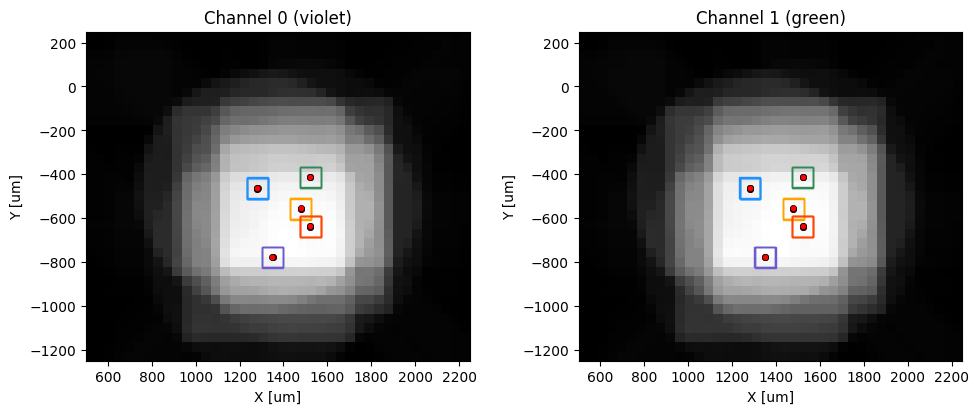

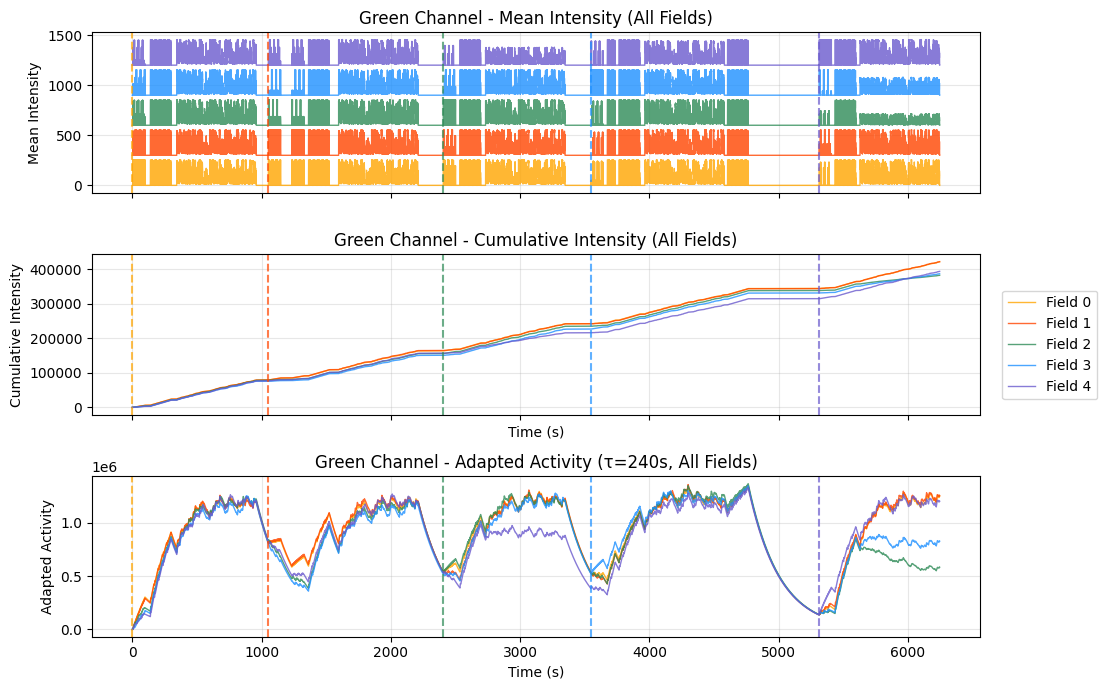

In [19]:
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[ 7,  9]) # F0
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[10, 13],) # F1
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[16, 18]) # F2
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[20, 24]) # F3
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[28, 30]) # F4
#movie_data = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[7,7]) # F0
movie_data, acc_image_norm, spatial_extent, df_valid = calc_spatial_exposure(CONSOL_PATH, params, ln_range=[ 7, 30]) # all fields

f_int_mean, f_int_cumul, f_adapted_activity, t_marks = calc_temporal_exposure(movie_data, params)

### Combined exposure summary figure

Left panel: exposure map (channel 0). Right panel: mean intensity and adapted activity, stacked, at 1.3x the width of the left panel and matching its total height.

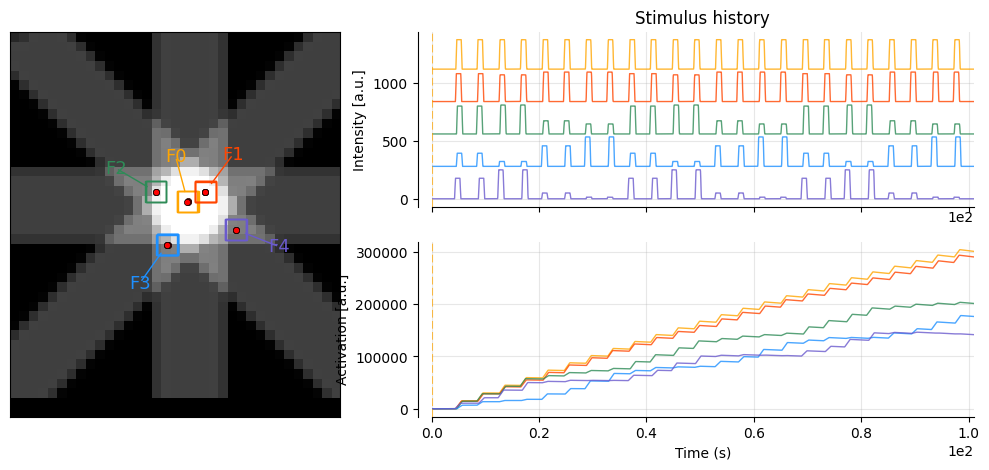

In [20]:
plot_exposure_summary(
    movie_data, spatial_extent, df_valid,
    f_int_mean, f_adapted_activity, t_marks, params,
    _ch_map=0, ln_range=[7, 7],
)

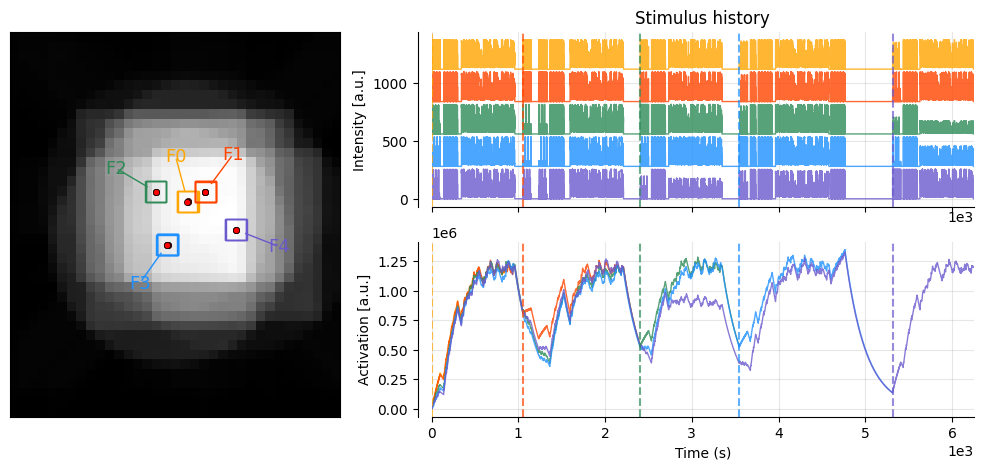

In [21]:
plot_exposure_summary(
    movie_data, spatial_extent, df_valid,
    f_int_mean, f_adapted_activity, t_marks, params,
    _ch_map=0, ln_range=[7, 30],
)